In [1]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

import os
import math
import random
from sklearn.metrics import classification_report as cr
from sklearn.metrics import roc_auc_score as auc

import torch
import torch.nn as nn
import torch.nn.functional as F

def seed_everything(seed: int):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True
    
seed_everything(42)
torch.__version__, torch.cuda.is_available()

('2.0.1', True)

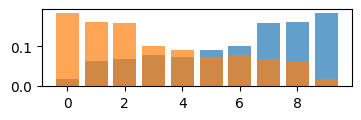

Creating Data: # 100


100%|████████████████████████████████████████████████████████████████████████████████| 50/50 [00:00<00:00, 1479.08it/s]

sample:  tensor([0, 1, 7, 8, 9]) 
 tensor([4, 2, 2, 2, 2, 1, 1]) tensor([0.])


In [2]:
num_stores = 10
probabilities = np.linspace(0, 1, num_stores) + np.random.random(num_stores)/3
probabilities /= probabilities.sum()

plt.figure(figsize=(4,1))
plt.bar(np.arange(num_stores), probabilities, alpha = 0.7) # class zero
plt.bar(np.arange(num_stores), probabilities[::-1], alpha = 0.7) # class one
plt.show()

def _categorical_distribution(probabilities=probabilities, class_=0):
    if class_: probabilities = probabilities[::-1]
    return np.random.choice(np.arange(num_stores), p=probabilities)

def create_data(num_datapoints=50):
    Xy = []
    print('Creating Data: #', num_datapoints*2)
    for i in tqdm(range(num_datapoints)): # data points
        samples = [_categorical_distribution() for _ in range(np.random.randint(4,20))]
        unique, counts = np.unique(samples, return_counts=True)
        Xy.append([torch.LongTensor(unique), torch.LongTensor(counts), torch.Tensor([0])])
        
        samples = [_categorical_distribution(class_=1) for _ in range(np.random.randint(4,20))]
        unique, counts = np.unique(samples, return_counts=True)
        distribution_counts = dict(zip(unique, counts))
        Xy.append([torch.LongTensor(unique), torch.LongTensor(counts), torch.Tensor([1])])
    
    return Xy

toy_dataset = create_data()
print('sample: ', toy_dataset[0][0], '\n', toy_dataset[1][1], toy_dataset[0][2])

In [3]:
# Define a simple neural network for binary classification
emb_dim = 16
class Classifier(nn.Module):
    def __init__(self, use_count_aware_pooling=False):
        super(Classifier, self).__init__()
        self.embedding = nn.Embedding(num_stores, emb_dim)

        self.W_q = nn.Linear(emb_dim, emb_dim)
        self.W_k = nn.Linear(emb_dim, emb_dim)
        self.W_v = nn.Linear(emb_dim, emb_dim)

        self.fc1 = nn.Linear(emb_dim, emb_dim)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(emb_dim, 1)
        self.sigmoid = nn.Sigmoid()
        
        self.use_count_aware_pooling = use_count_aware_pooling

    def forward(self, x):
        embs = self.embedding(x[0]) # stores
        
        q = self.W_q(embs)
        k = self.W_k(embs)
        v = self.W_v(embs)
        qk = torch.matmul(q, k.t())
        
        if self.use_count_aware_pooling:
            counts = torch.log(x[1]).float()[:, None] # counts
            qk = qk * counts
            
        attention_weights = F.softmax(qk / torch.sqrt(torch.tensor(x[0].size(-1))), dim=-1)
        attended_vectors = torch.matmul(attention_weights, v)
        emb = torch.mean(attended_vectors, dim=0)
        x = self.fc1(emb)
        x = self.act(x)
        x = self.fc2(x)
        return x

model1 = Classifier()
model2 = Classifier(use_count_aware_pooling=True)
model1(toy_dataset[0]), model2(toy_dataset[0]) # check

(tensor([0.3085], grad_fn=<AddBackward0>),
 tensor([0.2611], grad_fn=<AddBackward0>))

In [4]:
def train_classifier(model, dataset, num_epochs=1):
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
    criterion = torch.nn.BCEWithLogitsLoss()
    print('Training ...')
    for epoch in range(num_epochs):
        random.shuffle(dataset)
        for Xy in tqdm(dataset):
            optimizer.zero_grad()
            outputs = model(Xy)
            loss = criterion(outputs, Xy[2])
            loss.backward()
            optimizer.step()

def sigmoid(x): return 1 / (1 + math.exp(-x))
            
def evaluate_classifier(model, dataset):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for Xy in dataset:
            preds.append(sigmoid(model(Xy).item()))
            targets.append(int(Xy[2].item()))
    return np.array(preds), np.array(targets)

In [5]:
train_dataset = create_data(50000)
test_data = create_data(5000)

train_classifier(model1, train_dataset)
train_classifier(model2, train_dataset)

Creating Data: # 100000


100%|██████████████████████████████████████████████████████████████████████████| 50000/50000 [00:33<00:00, 1492.71it/s]


Creating Data: # 10000


100%|████████████████████████████████████████████████████████████████████████████| 5000/5000 [00:03<00:00, 1502.07it/s]


Training ...


100%|█████████████████████████████████████████████████████████████████████████| 100000/100000 [02:45<00:00, 604.97it/s]


Training ...


100%|█████████████████████████████████████████████████████████████████████████| 100000/100000 [02:49<00:00, 590.76it/s]


In [6]:
out1 = evaluate_classifier(model1, test_data)
out2 = evaluate_classifier(model2, test_data)
print('Model 1: AUC', auc(out1[1], out1[0]>0.5), '\n', cr(out1[1], out1[0]>0.5))
print('Model 2: AUC', auc(out2[1], out2[0]>0.5), '\n', cr(out2[1], out2[0]>0.5))

Model 1: AUC 0.8986000000000001 
               precision    recall  f1-score   support

           0       0.93      0.86      0.89      5000
           1       0.87      0.94      0.90      5000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000

Model 2: AUC 0.9411999999999999 
               precision    recall  f1-score   support

           0       0.93      0.95      0.94      5000
           1       0.95      0.93      0.94      5000

    accuracy                           0.94     10000
   macro avg       0.94      0.94      0.94     10000
weighted avg       0.94      0.94      0.94     10000

